# Prepare data
This notebook serve the purpose of preparing the data for the training of the model. It includes dataset formatting to the right format, splitting the dataset, cleaning it by removing the cases that we marked as too damaged, computing the common foreground mask, and statistics about the training data that will be used for the data augmentation and the training of the model.

## FIVES dataset
The dataset should have already been downloaded and extracted in the data directory.
The FIVES dataset should be located in EVAPORE/data/FIVES, and should have the following structure:
- FIVES/
    - test/
        - Ground truth/
        - Original/
    - train/
        - Ground truth/
        - Original/
    - clean_files_idx.txt
    - (optional) Quality Assessment.xlsx

Note: The clean_files_idx.txt is provided in the git repository, and contains the list of indices of the clean files in the dataset.

In [1]:
from utils.available_datasets import available_datasets

fives = available_datasets["FIVES"]

In [2]:
import os

fives_data_dir = fives.data_dir
fives_splits_filepath = fives.splits_filepath

print(f"FIVES dataset directory: {fives_data_dir}")

FIVES dataset directory: /home/morand/afs/EVAPORE/data/FIVES


### Format the dataset to the accepted format
Here we keep the original data, but you can delete it if you want to save storage

In [ ]:
from tqdm import tqdm
from shutil import copyfile
import json

def process_split(main_dir, split_name, start_index=0):
    src_img_dir = os.path.join(main_dir, split_name, "Original")
    src_gt_dir = os.path.join(main_dir, split_name, "Ground truth")

    dst_img_dir = os.path.join(main_dir, "img")
    dst_gt_dir = os.path.join(main_dir, "gt")
    os.makedirs(dst_img_dir, exist_ok=True)
    os.makedirs(dst_gt_dir, exist_ok=True)

    filenames_list = [f for f in os.listdir(src_img_dir) if f.endswith(('.png'))]

    # --- Process each image and ground truth ---
    idx_list = []
    for filename in tqdm(filenames_list):
        i = int(filename.split('_')[0]) + start_index
        id = f"FIVES_{i:03d}"
        idx_list.append(id)
        new_filename = f"{id}.png"

        src_img_path = os.path.join(src_img_dir, filename)
        dst_img_path = os.path.join(dst_img_dir, new_filename)
        copyfile(src_img_path, dst_img_path)

        src_gt_path = os.path.join(src_gt_dir, filename)
        dst_gt_path = os.path.join(dst_gt_dir, new_filename)
        copyfile(src_gt_path, dst_gt_path)

    return idx_list
    
fives_splits = {}
fives_train_idx = process_split(fives_data_dir, "train")
fives_train_idx.sort()
fives_test_idx = process_split(fives_data_dir, "test", start_index=len(fives_train_idx))
fives_test_idx.sort()
fives_splits['train'] = fives_train_idx
fives_splits['test'] = fives_test_idx

with open(fives_splits_filepath, 'w') as f:
    json.dump(fives_splits, f, indent=4)

### Data cleaning
We import the clean file indices that we manually identified and add them to the splits

In [ ]:
clean_files_idx_filepath = os.path.join(fives_data_dir, "clean_files_idx.txt")
if not os.path.exists(clean_files_idx_filepath):
    raise ValueError(f"File {clean_files_idx_filepath} does not exist.")
with open(clean_files_idx_filepath, 'r') as f:
    clean_files_idx = [line.strip() for line in f.readlines()]

print(f"Number of clean files: {len(clean_files_idx)}")
print(f"First 5 clean file indices: {clean_files_idx[:5]}")

fives_splits['train_clean'] = clean_files_idx

with open(fives_splits_filepath, 'w') as f:
    json.dump(fives_splits, f, indent=4)

### Foreground mask computation
Compute the common foreground mask across all images in the train set, which will be used to refine the predictions of the model by masking out irrelevant background areas.
This will also be used in the metrics computation to focus only on the relevant areas of the images.

We merge the foreground mask along the images to avoid having noise due to the thresholding with an arbitrary threshold value (here 4)

In [3]:
from image_segmentation.data.foreground_mask import compute_foreground_mask

img_dir = os.path.join(fives_data_dir, 'train/Original/')
img_paths = [os.path.join(img_dir, fname) for fname in os.listdir(img_dir) if fname.endswith('.png')]

threshold = 4
debug_i = 20

common_mask = compute_foreground_mask(img_paths, threshold=threshold, debug_i=debug_i)

100%|██████████| 20/20 [00:14<00:00,  1.38it/s]


Plot and save the foreground common mask

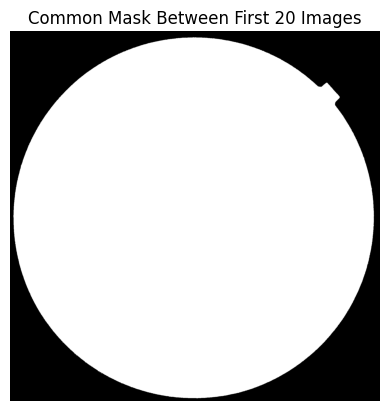

In [4]:
import matplotlib.pyplot as plt
import torch

plt.imshow(common_mask, cmap='gray')
plt.title(f"Common Mask Between First {debug_i} Images")
plt.axis('off')
plt.show()

foreground_mask_dir = os.path.join(fives_data_dir, "foreground_masks")
os.makedirs(foreground_mask_dir, exist_ok=True)

torch.save(torch.from_numpy(common_mask), os.path.join(foreground_mask_dir, "FIVES.pt"))

### Test and visualize the dataset

We intialize the dataset object, that is used to load the data. We also initialize the datamodule, that is used to split the data into train, val and test sets, apply the transformations and augmentations, and create the dataloaders.

In [6]:
from image_segmentation.data import ImageDatamodule

fives_datamodule = ImageDatamodule(fives_data_dir, 
                             split_file_path=fives_splits_filepath,
                             train_split_name='train_clean',
                             val_split_ratio=0.2,
                             train_transforms=None,
                             val_transforms=None,
                             test_transforms=None,
                             num_workers=0,
                             train_batch_size=4,
                             val_batch_size=1,
                             seed=42,
                             shuffle_train=True)
fives_datamodule.setup()

Dataset split: Train=440, Val=109, Test=200


We precompute the dataset statistics for the 'train_clean' split using the combined indices of train and val splits, without the test split, to ensure that the statistics reflect only the data used for training and validation, and not the unseen test data. This allows us to have a more accurate understanding of the data distribution that the model will be trained on, without any influence from the test set which is meant to evaluate generalization performance. 

We also compute thoses statistics on all the image and on only the foreground pixels, using the precomputed common foreground mask, to get a better insight into the distribution of pixel values in the regions of interest that the model will learn to segment.

In [9]:
# We use a FOV of 50 degrees for the FIVES dataset, as specified in the dataset documentation.
stats = fives_datamodule.dataset.get_dataset_stats(split_name='train_clean', split_indices=fives_datamodule.train_indices + fives_datamodule.val_indices, fov = 50)
print("FIVES Dataset Statistics for 'train_clean' split:")
print(stats)

Loading dataset stats for split 'train_clean' from /home/morand/afs/EVAPORE/data/FIVES/image_stats.json...
Saving dataset stats for split 'train_clean' to /home/morand/afs/EVAPORE/data/FIVES/image_stats.json...
FIVES Dataset Statistics for 'train_clean' split:
{'image_width': 2048, 'image_height': 2048, 'n_channels': 3, 'full_image': {'mean': [0.34109341271750915, 0.15390528234329162, 0.06589737845472787], 'std': [0.24093703398860752, 0.12289663505183519, 0.05547727262863106]}, 'foreground': {'mean': [0.44817834316662786, 0.20165531537789622, 0.08165605062841931], 'std': [0.17302453064340234, 0.1008530268569081, 0.05196561252496086]}, 'field_of_view_degrees': 50, 'estimated_resolution_mm_per_pixel': 0.010492961434835649, 'median_foreground_width_pixels': 1996}


Image batch shape: torch.Size([4, 2048, 2048, 3])
Ground truth batch shape: torch.Size([4, 1, 2048, 2048])


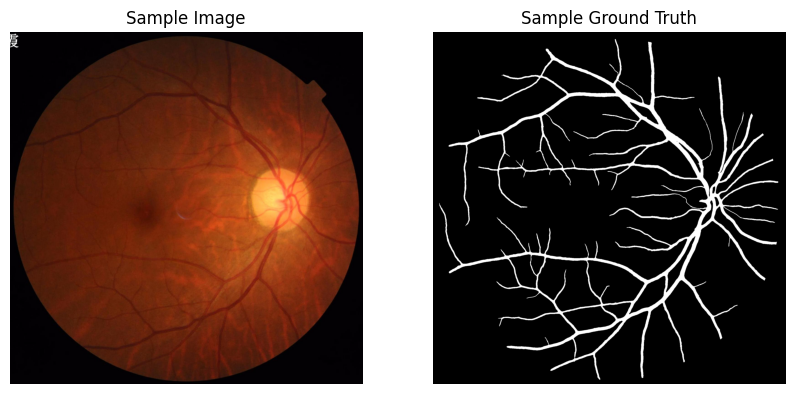

In [10]:
import matplotlib.pyplot as plt

fives_train_dataloader = fives_datamodule.train_dataloader()
img, gt = next(iter(fives_train_dataloader))
print(f"Image batch shape: {img.shape}")
print(f"Ground truth batch shape: {gt.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img[0].numpy())
plt.title("Sample Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(gt[0].squeeze().numpy(), cmap='gray')
plt.title("Sample Ground Truth")
plt.axis('off')
plt.show()

After executing this notebook, the FIVES dataset folder should have the following structure:
- FIVES/
    - (optional) test/
        - Ground truth/
        - Original/
    - (optional) train/
        - Ground truth/
        - Original/
    - img/
    - gt/
    - foreground_masks/
    - image_stats.json
    - splits.json
    - clean_files_idx.txt
    - (optional) Quality Assessment.xlsx

Now that the datasets are in the right format, you can continue on the [U-Net pretraining notebook (2)](./02_pretrain_unet.ipynb)